In [7]:
import sympy as sp

sp.init_printing()

# Symbols
t = sp.symbols("t", real=True)

# Signals
x = sp.Function("x")
y = sp.Function("y")


def _signal_derivative_terms(expr, funcs):
    """
    Finder x(t), y(t) og deres afledte i udtrykket.
    """
    terms = []

    for f in funcs:
        base = f(t)

        if expr.has(base):
            terms.append(base)

        for d in expr.atoms(sp.Derivative):
            if d.expr == base and all(v == t for v in d.variables):
                terms.append(d)

    unique_terms = []
    for term in terms:
        if term not in unique_terms:
            unique_terms.append(term)

    return unique_terms


def _make_dummy_substitution(terms):
    """
    Erstatter x(t), x'(t), y(t), y'(t), ... med almindelige symboler.
    Bruges til linearitetstjek.
    """
    mapping = {}

    for term in terms:
        if isinstance(term, sp.Derivative):
            base = term.expr
            order = len(term.variables)
        else:
            base = term
            order = 0

        name = str(base.func)
        symbol_name = f"{name}{order}"
        mapping[term] = sp.Symbol(symbol_name)

    return mapping


def _find_shifted_inputs(expr):
    """
    Finder inputled som x(t+a), x(t-a), x(2*t), osv.
    """
    shifted = []

    for atom in expr.atoms(sp.Function):
        if atom.func == x:
            arg = atom.args[0]
            shift = sp.simplify(arg - t)
            shifted.append((atom, arg, shift))

    return shifted


def _causality_check(expr):
    """
    Simpelt kausalitetstjek.

    Ikke kausal hvis der findes x(t+a) med a > 0.
    Kausal hvis input kun er x(t), afledte af x(t), eller forsinkede x(t-a).
    Ukendte tidsargumenter markeres som usikre.
    """
    shifted_inputs = _find_shifted_inputs(expr)

    future_inputs = []
    delayed_inputs = []
    uncertain_inputs = []

    for atom, arg, shift in shifted_inputs:
        if shift == 0:
            continue

        # Kun simple shifts x(t+a) eller x(t-a)
        if sp.simplify(sp.diff(arg, t)) != 1:
            uncertain_inputs.append(atom)
            continue

        try:
            shift_num = float(sp.N(shift))

            if shift_num > 0:
                future_inputs.append(atom)
            elif shift_num < 0:
                delayed_inputs.append(atom)

        except Exception:
            uncertain_inputs.append(atom)

    if future_inputs:
        return False, future_inputs, delayed_inputs, uncertain_inputs

    if uncertain_inputs:
        return None, future_inputs, delayed_inputs, uncertain_inputs

    return True, future_inputs, delayed_inputs, uncertain_inputs


def ltic_check(eq, show_details=True):
    """
    Simpelt LTIC-tjek for en differentialligning.

    Eksempel:
        eq = sp.Eq(
            sp.diff(y(t), t, 2) + sp.diff(y(t), t) + 5*y(t),
            sp.sin(t)*x(t)
        )

    Tjekker:
        Linearitet
        Tidsinvarians
        Kausalitet

    LTIC i denne funktion betyder:
        lineær + tidsinvariant + kausal
    """

    # Skriv alt på formen expr = 0
    expr = sp.simplify(eq.lhs - eq.rhs)

    # Find x, y og afledte
    terms = _signal_derivative_terms(expr, funcs=[x, y])
    mapping = _make_dummy_substitution(terms)

    expr_dummy = expr.xreplace(mapping)
    variables = list(mapping.values())

    # ---------- Linearitet ----------
    try:
        poly = sp.Poly(expr_dummy, *variables, domain="EX")
        max_degree = poly.total_degree()

        zero_test = sp.simplify(
            expr_dummy.subs({v: 0 for v in variables})
        )

        is_linear = (max_degree <= 1) and (zero_test == 0)

    except Exception:
        is_linear = False

    # ---------- Tidsinvarians ----------
    if is_linear:
        time_varying_coeffs = []

        for v in variables:
            coeff = sp.simplify(sp.diff(expr_dummy, v))

            if coeff.has(t):
                time_varying_coeffs.append((v, coeff))

        is_time_invariant = len(time_varying_coeffs) == 0

    else:
        time_varying_coeffs = []
        is_time_invariant = None

    # ---------- Kausalitet ----------
    is_causal, future_inputs, delayed_inputs, uncertain_inputs = _causality_check(expr)

    # ---------- LTIC ----------
    is_ltic = (
        is_linear is True
        and is_time_invariant is True
        and is_causal is True
    )

    result = {
        "linear": is_linear,
        "time_invariant": is_time_invariant,
        "causal": is_causal,
        "ltic": is_ltic,
        "expr_zero_form": expr,
        "dummy_expr": expr_dummy,
        "substitution": mapping,
        "time_varying_coeffs": time_varying_coeffs,
        "future_inputs": future_inputs,
        "delayed_inputs": delayed_inputs,
        "uncertain_inputs": uncertain_inputs,
    }

    if show_details:
        print("LTIC check")
        print("==========")

        print("Ligning på formen expr = 0:")
        display(expr)

        print("Dummy-form:")
        display(expr_dummy)

        print("Lineær:")
        print("Ja" if is_linear else "Nej")

        print("Tidsinvariant:")
        if is_time_invariant is None:
            print("Kan ikke vurderes sikkert, fordi ligningen ikke er lineær.")
        else:
            print("Ja" if is_time_invariant else "Nej")

        print("Kausal:")
        if is_causal is None:
            print("Kan ikke vurderes sikkert.")
        else:
            print("Ja" if is_causal else "Nej")

        print("LTIC:")
        print("Ja" if is_ltic else "Nej")

        if time_varying_coeffs:
            print()
            print("Tidsafhængige koefficienter fundet:")
            for var, coeff in time_varying_coeffs:
                display(sp.Eq(var, coeff))

        if future_inputs:
            print()
            print("Fremtidige input fundet, derfor ikke kausal:")
            for item in future_inputs:
                display(item)

        if delayed_inputs:
            print()
            print("Forsinkede input fundet, stadig kausal:")
            for item in delayed_inputs:
                display(item)

        if uncertain_inputs:
            print()
            print("Usikre inputargumenter fundet:")
            for item in uncertain_inputs:
                display(item)

    return result

LTIC check
Ligning på formen expr = 0:


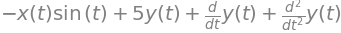

Dummy-form:


Lineær:
Ja
Tidsinvariant:
Nej
Kausal:
Ja
LTIC:
Nej

Tidsafhængige koefficienter fundet:


In [9]:
# Eksempel:
eq = sp.Eq(
    sp.diff(y(t), t, 2) + sp.diff(y(t), t) + 5*y(t),
    sp.sin(t)*x(t)
)

res = ltic_check(eq)

# Note om kausalitet med forskudte signaler:
# x(t + tau), tau > 0  -> fremtidigt input -> ikke kausal
# x(t - tau), tau > 0  -> forsinket input -> kausal
# y(t - tau), tau > 0  -> tidligere output / memory -> normalt stadig kausal
# y(t + tau), tau > 0  -> fremtidigt output -> ikke almindelig kausal realisering
#
# Konstant tidsforskydning, fx x(t - tau) eller y(t - tau), gør ikke i sig selv systemet tidsvarierende.
# Tidsafhængig skalering/forskydning, fx x(2*t), x(t**2), x(t - t**2), peger normalt på tidsvarierende system.
# Led som y(t - tau) gør modellen til en delay differential equation, ikke en almindelig ODE.